#Descargando los datasets desde kaggle
Usamos kagglehub para bajar el dataset directamente al entorno, así no hay que subir los archivos a mano y cualquiera puede reproducir el notebook.

In [29]:
!pip install -q kagglehub
import kagglehub

path = kagglehub.dataset_download("tuannguyenvananh/pokemon-dataset-with-team-combat")
print("Archivos descargados en:", path)

import os
for f in os.listdir(path):
    print(f)

Archivos descargados en: C:\Users\smith\.cache\kagglehub\datasets\tuannguyenvananh\pokemon-dataset-with-team-combat\versions\6
combats.csv
pokemon.csv
pokemon_id_each_team.csv
team_combat.csv


#Cargando los datos y viendo la estructura de estos

In [30]:
import pandas as pd
import numpy as np

DATA_DIR = path

# Cargar automáticamente todos los CSV que haya en la carpeta
csv_files = [f for f in os.listdir(DATA_DIR) if f.endswith('.csv')]
print("CSVs encontrados:", csv_files)

dfs = {}
for f in csv_files:
    name = f.replace('.csv', '')
    dfs[name] = pd.read_csv(os.path.join(DATA_DIR, f))
    print(f"\n--- {f} ---")
    print("Shape:", dfs[name].shape)
    print(dfs[name].head())

CSVs encontrados: ['combats.csv', 'pokemon.csv', 'pokemon_id_each_team.csv', 'team_combat.csv']

--- combats.csv ---
Shape: (50000, 3)
   First_pokemon  Second_pokemon  Winner
0            266             298     298
1            702             701     701
2            191             668     668
3            237             683     683
4            151             231     151

--- pokemon.csv ---
Shape: (800, 12)
   #           Name Type 1  Type 2  HP  Attack  Defense  Sp. Atk  Sp. Def  \
0  1      Bulbasaur  Grass  Poison  45      49       49       65       65   
1  2        Ivysaur  Grass  Poison  60      62       63       80       80   
2  3       Venusaur  Grass  Poison  80      82       83      100      100   
3  4  Mega Venusaur  Grass  Poison  80     100      123      122      120   
4  5     Charmander   Fire     NaN  39      52       43       60       50   

   Speed  Generation  Legendary  
0     45           1      False  
1     60           1      False  
2     80        

| Tabla | Filas x columnas | Qué representa |
|---|---|---|
| pokemon | 800 x 12 | Catálogo de Pokémon: tipos, stats base, generación y si es legendario |
| combats | 50 000 x 3 | Duelos **1v1**: quién peleó contra quién y quién ganó |
| pokemon_id_each_team | 100 x 7 | Los 6 Pokémon que forman cada uno de los 100 equipos |
| team_combat | 10 000 x 3 | Enfrentamientos **equipo vs equipo** y su resultado (**nuestra tabla objetivo**) |

#EDA
Empezamos por la tabla pokemon, que es la base de todas las variables que vamos a construir después.

In [31]:
pokemon_df = dfs.get('pokemon')  # ajusta el nombre exacto si difiere

print("Información general:")
pokemon_df.info()

print("\nValores nulos por columna:")
print(pokemon_df.isnull().sum())

print("\nEstadísticas descriptivas (numéricas):")
display(pokemon_df.describe())

print("\nEstadísticas descriptivas (categóricas):")
display(pokemon_df.describe(include='object'))

print("\n% de pokemon con un solo tipo:", pokemon_df['Type 2'].isnull().mean()*100, "%")

# Duplicados
print("\nFilas duplicadas:", pokemon_df.duplicated().sum())

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   #           800 non-null    int64 
 1   Name        800 non-null    object
 2   Type 1      800 non-null    object
 3   Type 2      414 non-null    object
 4   HP          800 non-null    int64 
 5   Attack      800 non-null    int64 
 6   Defense     800 non-null    int64 
 7   Sp. Atk     800 non-null    int64 
 8   Sp. Def     800 non-null    int64 
 9   Speed       800 non-null    int64 
 10  Generation  800 non-null    int64 
 11  Legendary   800 non-null    bool  
dtypes: bool(1), int64(8), object(3)
memory usage: 69.7+ KB

Valores nulos por columna:
#               0
Name            0
Type 1          0
Type 2        386
HP              0
Attack          0
Defense         0
Sp. Atk         0
Sp. Def         0
Speed           0
Generation      0
Legendary       0
dtype: int

,#,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation
count,800.0000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.00000
mean,400.5000,69.258750,79.001250,73.842500,72.820000,71.902500,68.277500,3.32375
std,231.0844,25.534669,32.457366,31.183501,32.722294,27.828916,29.060474,1.66129
min,1.0000,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000,1.00000
25%,200.7500,50.000000,55.000000,50.000000,49.750000,50.000000,45.000000,2.00000
50%,400.5000,65.000000,75.000000,70.000000,65.000000,70.000000,65.000000,3.00000
75%,600.2500,80.000000,100.000000,90.000000,95.000000,90.000000,90.000000,5.00000
max,800.0000,255.000000,190.000000,230.000000,194.000000,230.000000,180.000000,6.00000



Estadísticas descriptivas (categóricas):


,Name,Type 1,Type 2
count,800,800,414
unique,800,18,18
top,Pumpkaboo Super Size,Water,Flying
freq,1,112,97



% de pokemon con un solo tipo: 48.25 %

Filas duplicadas: 0


#Distribuciones
Miramos cómo se reparten los 6 stats base, los tipos y los legendarios.

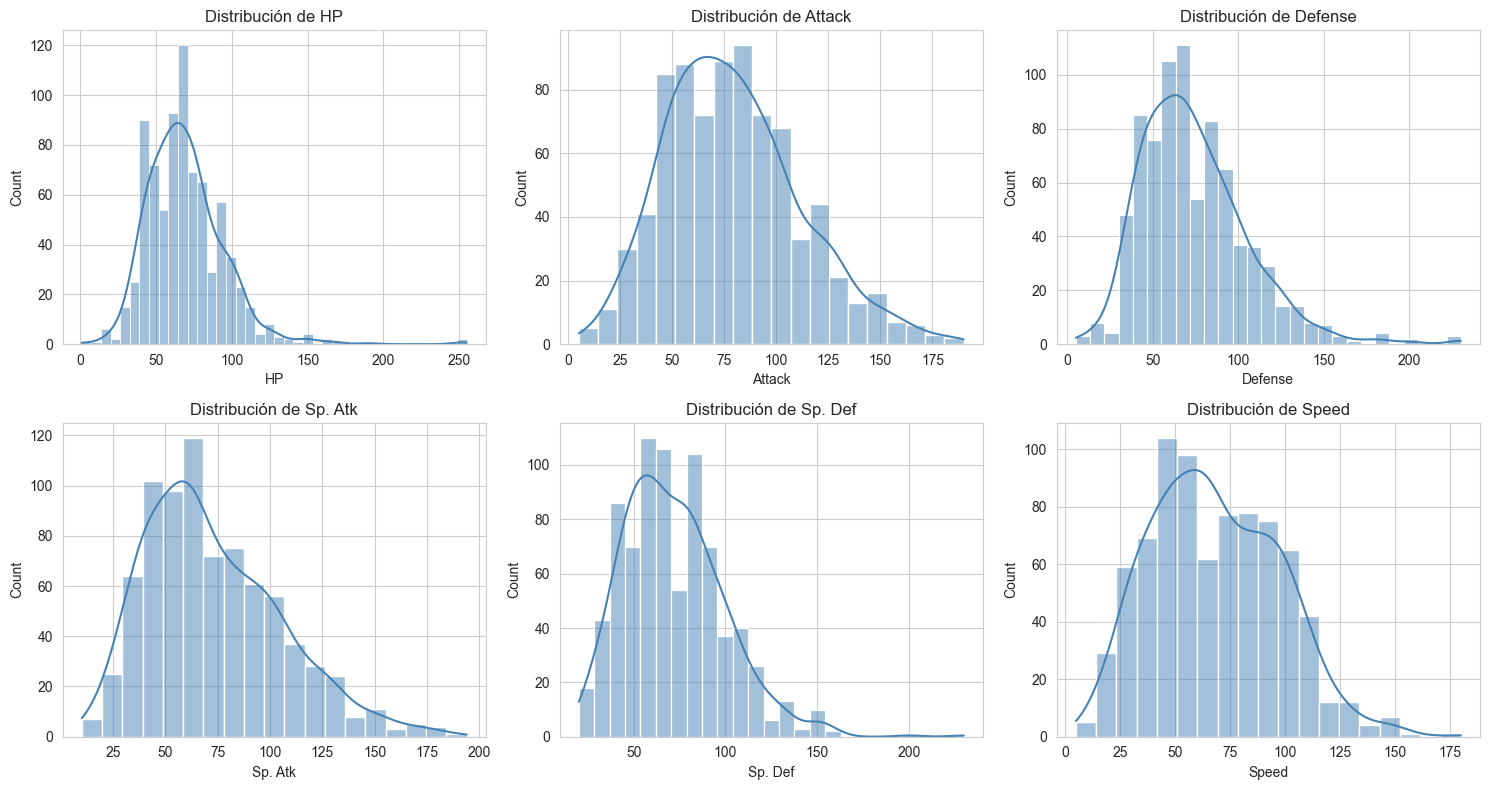

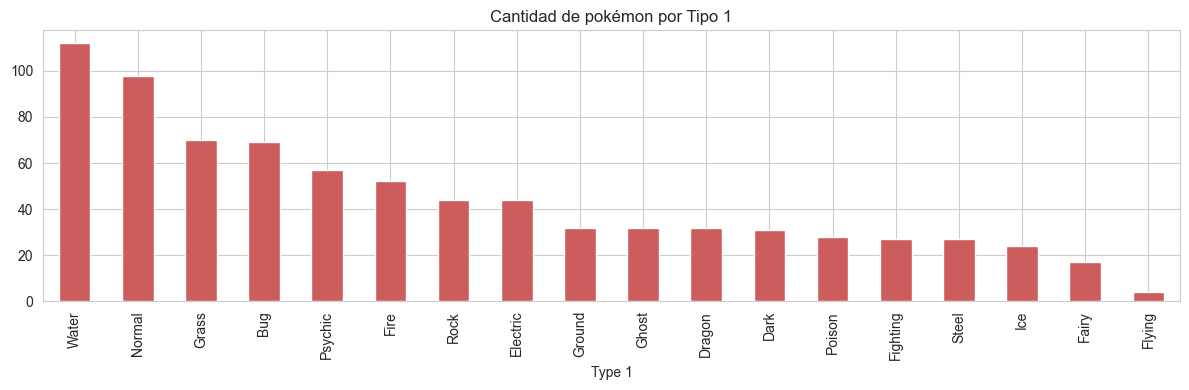

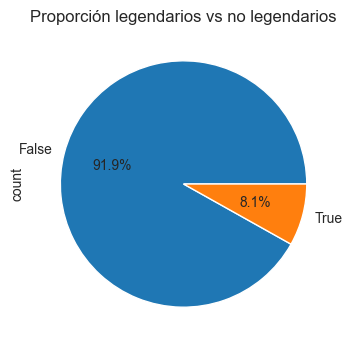

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

stat_cols = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(stat_cols):
    sns.histplot(pokemon_df[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribución de {col}')
plt.tight_layout()
plt.show()

# Tipos primarios más comunes
plt.figure(figsize=(12,4))
pokemon_df['Type 1'].value_counts().plot(kind='bar', color='indianred')
plt.title('Cantidad de pokémon por Tipo 1')
plt.tight_layout()
plt.show()

# Legendarios
plt.figure(figsize=(4,4))
pokemon_df['Legendary'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Proporción legendarios vs no legendarios')
plt.show()

#Matriz de correlacion
Queremos ver qué stats se mueven juntos. Esta matriz es entre stats individuales de cada pokémon; más abajo haremos lo mismo con las diferencias entre equipos.

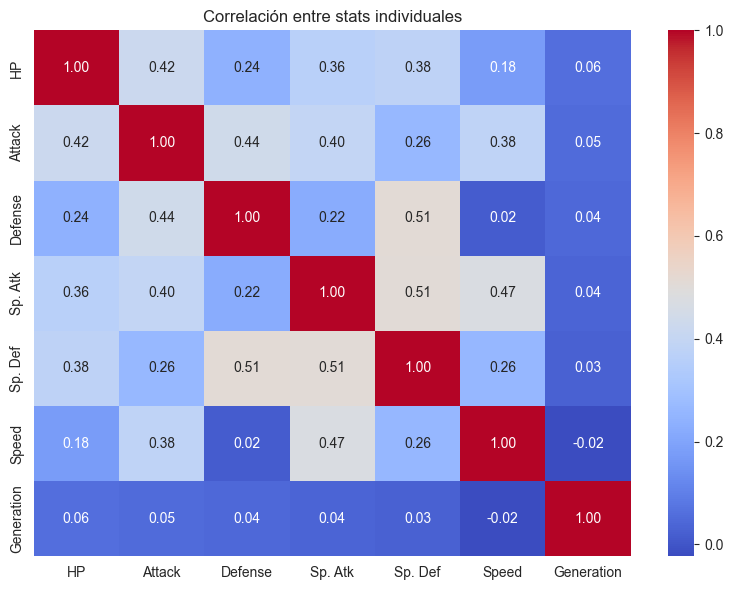

In [33]:
plt.figure(figsize=(8,6))
sns.heatmap(pokemon_df[stat_cols + ['Generation']].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlación entre stats individuales")
plt.tight_layout()
plt.show()

#Más victorias 1v1
Miramos la tabla combats (duelos individuales) para tener una primera pista de qué características hacen ganar.

El First_pokemon gana el 47.2% de las veces


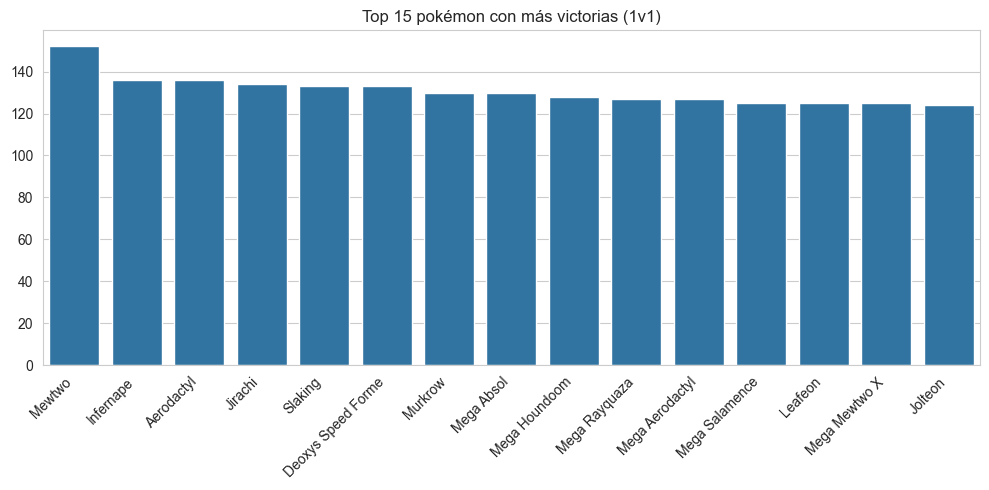

,Name,win_rate
#,,
155,Mega Aerodactyl,0.984496
513,Weavile,0.974790
704,Tornadus Therian Forme,0.968000
20,Mega Beedrill,0.966387
154,Aerodactyl,0.964539
477,Mega Lopunny,0.961240
727,Greninja,0.960630
717,Meloetta Pirouette Forme,0.959350
165,Mega Mewtwo Y,0.952000


In [34]:
combats_df = dfs['combats']

# Balance: ¿gana más seguido el "First_pokemon" o el "Second_pokemon"?
first_wins = (combats_df['Winner'] == combats_df['First_pokemon']).mean()
print(f"El First_pokemon gana el {first_wins*100:.1f}% de las veces")

# Top 15 pokemon con más victorias
win_counts = combats_df['Winner'].value_counts().head(15)
win_names = pokemon_df.set_index('#').loc[win_counts.index, 'Name']
plt.figure(figsize=(10,5))
sns.barplot(x=win_names.values, y=win_counts.values)
plt.xticks(rotation=45, ha='right')
plt.title('Top 15 pokémon con más victorias (1v1)')
plt.tight_layout()
plt.show()

# Total de combates por pokemon vs. % de victorias -> tasa de victoria real
appearances = pd.concat([combats_df['First_pokemon'], combats_df['Second_pokemon']]).value_counts()
win_rate = (combats_df['Winner'].value_counts() / appearances).fillna(0)
win_rate_df = pokemon_df.set_index('#').join(win_rate.rename('win_rate'))
display(win_rate_df.sort_values('win_rate', ascending=False)[['Name','win_rate']].head(10))

#Construccion features de equipo
Se buscan los 6 pokémon que lo componen y se calculan variables agregadas (suma y promedio de cada stat, cantidad de legendarios). Esto convierte "6 pokémon individuales" en "un perfil numérico de equipo".

In [35]:
teams_df = dfs['pokemon_id_each_team']
team_combat_df = dfs['team_combat']

pokemon_cols = ['0','1','2','3','4','5']  # ids de los 6 pokemon del equipo
pokemon_stats = pokemon_df.set_index('#')[stat_cols + ['Legendary']]

def build_team_features(team_id):
    row = teams_df[teams_df['#'] == team_id]
    if row.empty:
        return None
    ids = row[pokemon_cols].values.flatten()
    stats = pokemon_stats.loc[ids]
    feats = {
        'team_id': team_id,
        'sum_HP': stats['HP'].sum(), 'mean_HP': stats['HP'].mean(),
        'sum_Attack': stats['Attack'].sum(), 'mean_Attack': stats['Attack'].mean(),
        'sum_Defense': stats['Defense'].sum(), 'mean_Defense': stats['Defense'].mean(),
        'sum_SpAtk': stats['Sp. Atk'].sum(), 'mean_SpAtk': stats['Sp. Atk'].mean(),
        'sum_SpDef': stats['Sp. Def'].sum(), 'mean_SpDef': stats['Sp. Def'].mean(),
        'sum_Speed': stats['Speed'].sum(), 'mean_Speed': stats['Speed'].mean(),
        'n_legendary': stats['Legendary'].sum(),
    }
    return feats

team_features = pd.DataFrame([build_team_features(tid) for tid in teams_df['#']])
display(team_features.head())

,team_id,sum_HP,mean_HP,sum_Attack,mean_Attack,sum_Defense,mean_Defense,sum_SpAtk,mean_SpAtk,sum_SpDef,mean_SpDef,sum_Speed,mean_Speed,n_legendary
0,1,315,52.500000,385,64.166667,342,57.000000,515,85.833333,475,79.166667,573,95.500000,0
1,2,386,64.333333,430,71.666667,480,80.000000,495,82.500000,420,70.000000,394,65.666667,0
2,3,498,83.000000,625,104.166667,442,73.666667,350,58.333333,533,88.833333,475,79.166667,0
3,4,468,78.000000,520,86.666667,434,72.333333,430,71.666667,405,67.500000,411,68.500000,0
4,5,360,60.000000,373,62.166667,348,58.000000,359,59.833333,366,61.000000,369,61.500000,0


#Merge features equpo con team_combat

In [36]:
merged = team_combat_df.merge(team_features.add_suffix('_first'),
                               left_on='first', right_on='team_id_first') \
                        .merge(team_features.add_suffix('_second'),
                               left_on='second', right_on='team_id_second')

# Diferencias entre equipos (features fuertes para el modelo)
diff_cols_base = ['sum_HP','sum_Attack','sum_Defense','sum_SpAtk','sum_SpDef','sum_Speed','n_legendary']
for col in diff_cols_base:
    merged[f'diff_{col}'] = merged[f'{col}_first'] - merged[f'{col}_second']

display(merged.head())

,first,second,winner,team_id_first,sum_HP_first,mean_HP_first,sum_Attack_first,mean_Attack_first,sum_Defense_first,mean_Defense_first,...,sum_Speed_second,mean_Speed_second,n_legendary_second,diff_sum_HP,diff_sum_Attack,diff_sum_Defense,diff_sum_SpAtk,diff_sum_SpDef,diff_sum_Speed,diff_n_legendary
0,1,1,1,1,315,52.5,385,64.166667,342,57.0,...,573,95.500000,0,0,0,0,0,0,0,0
1,1,2,0,1,315,52.5,385,64.166667,342,57.0,...,394,65.666667,0,-71,-45,-138,20,55,179,0
2,1,3,1,1,315,52.5,385,64.166667,342,57.0,...,475,79.166667,0,-183,-240,-100,165,-58,98,0
3,1,4,0,1,315,52.5,385,64.166667,342,57.0,...,411,68.500000,0,-153,-135,-92,85,70,162,0
4,1,5,0,1,315,52.5,385,64.166667,342,57.0,...,369,61.500000,0,-45,12,-6,156,109,204,0


#EDA de combates por equipo

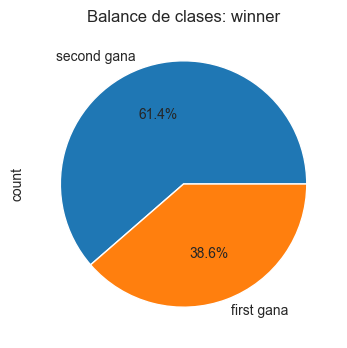

winner
1    0.6139
0    0.3861
Name: proportion, dtype: float64


,diff_sum_HP,diff_sum_Attack,diff_sum_Defense,diff_sum_SpAtk,diff_sum_SpDef,diff_sum_Speed,diff_n_legendary
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000
mean,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
std,94.289469,109.244682,97.860853,103.600813,77.433194,87.07649,0.824662
min,-409.000000,-380.000000,-330.000000,-410.000000,-304.000000,-330.00000,-2.000000
25%,-57.000000,-73.000000,-65.000000,-69.000000,-48.250000,-55.00000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
75%,57.000000,73.000000,65.000000,69.000000,48.250000,55.00000,0.000000
max,409.000000,380.000000,330.000000,410.000000,304.000000,330.00000,2.000000


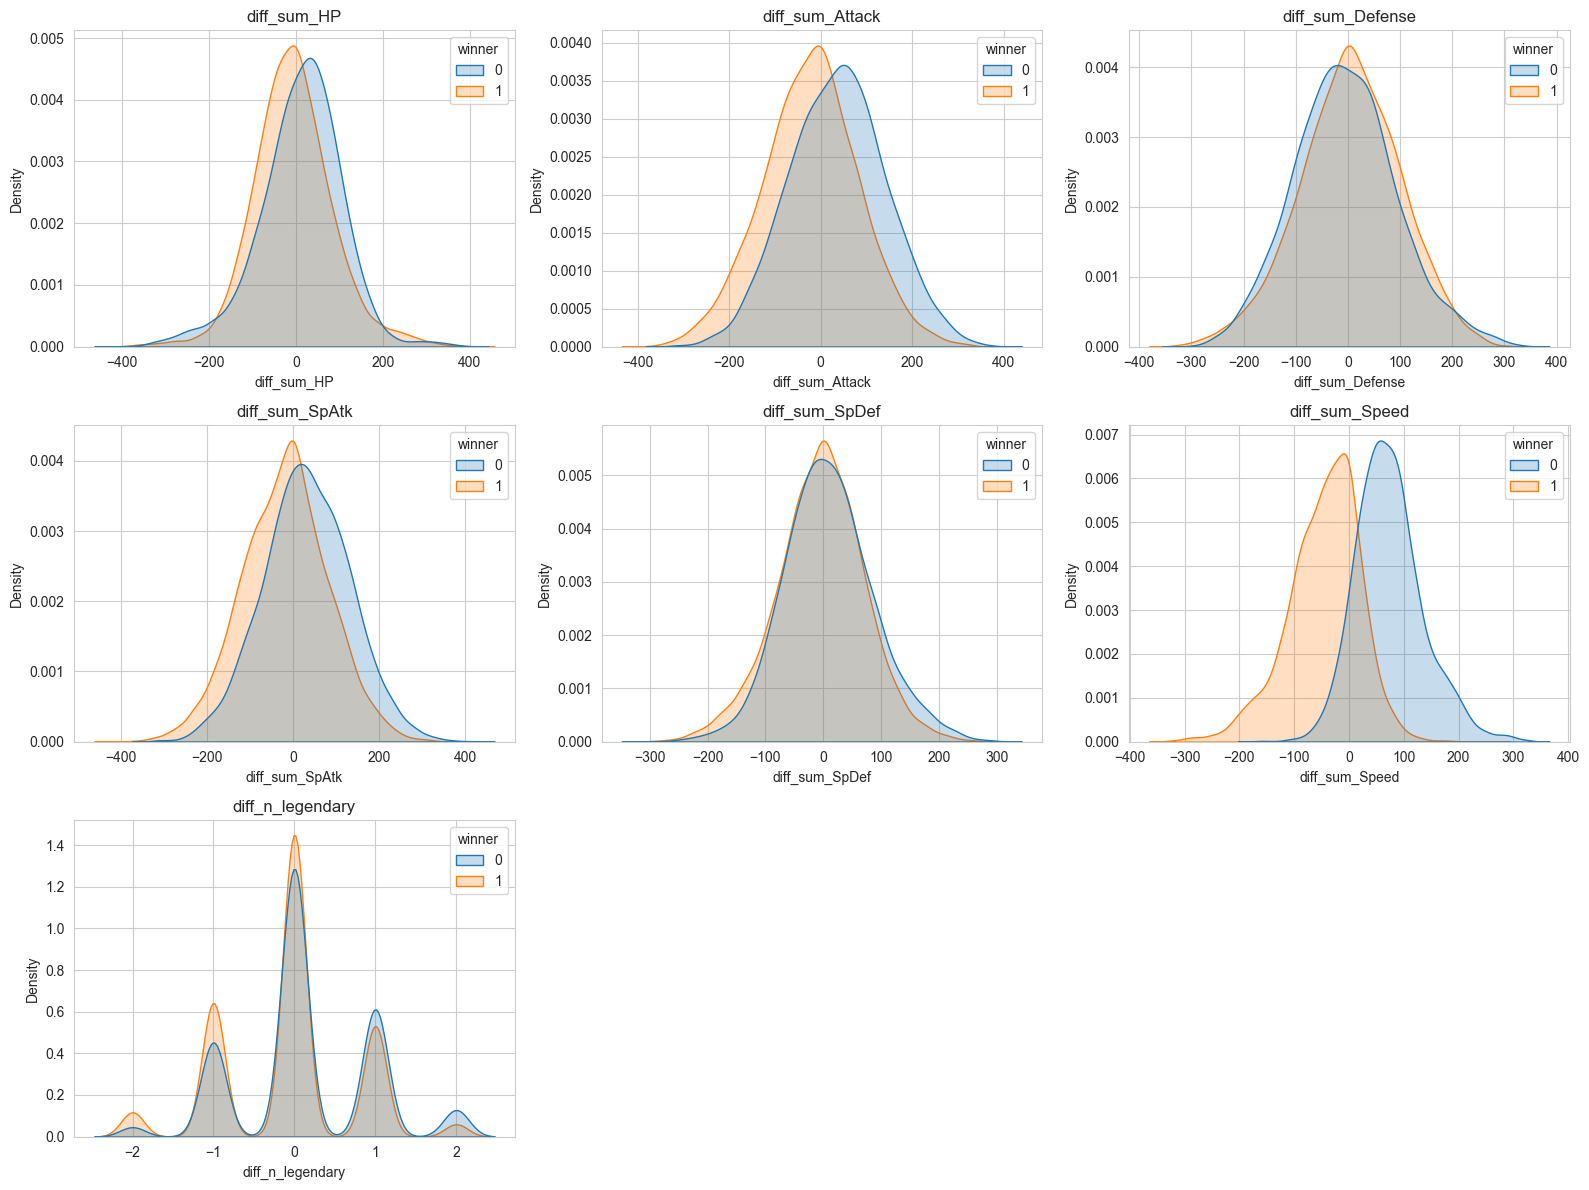


Correlación de cada diferencia de stat con 'winner':
winner              1.000000
diff_sum_Defense    0.045907
diff_sum_SpDef     -0.089124
diff_sum_HP        -0.092513
diff_n_legendary   -0.123546
diff_sum_SpAtk     -0.237240
diff_sum_Attack    -0.265302
diff_sum_Speed     -0.666477
Name: winner, dtype: float64


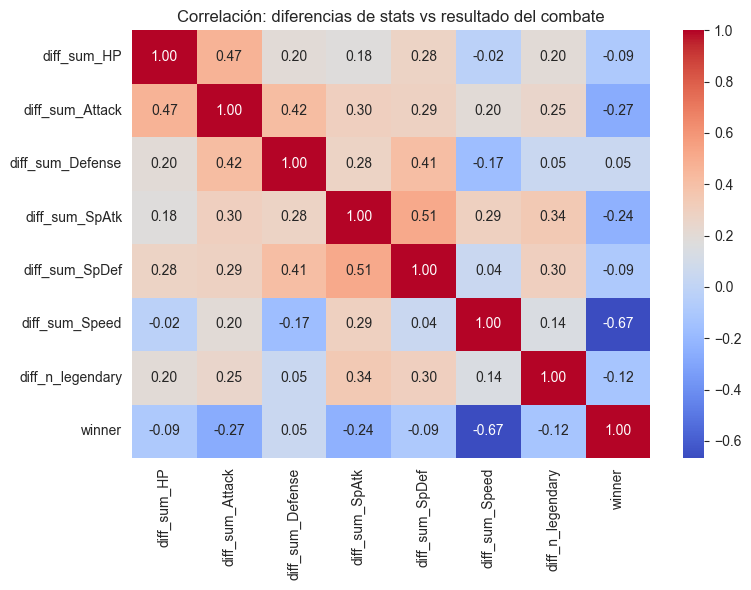

In [37]:
# Balance de la clase objetivo (fundamental antes de modelar)
plt.figure(figsize=(4,4))
merged['winner'].value_counts().plot(kind='pie', autopct='%1.1f%%', labels=['second gana','first gana'])
plt.title('Balance de clases: winner')
plt.show()
print(merged['winner'].value_counts(normalize=True))

# Estadísticas descriptivas de las diferencias
display(merged[[f'diff_{c}' for c in diff_cols_base]].describe())

# Distribución de las diferencias, separadas por resultado
diff_cols = [f'diff_{c}' for c in diff_cols_base]
fig, axes = plt.subplots(3, 3, figsize=(16,12))
axes = axes.flatten()
for i, col in enumerate(diff_cols):
    sns.kdeplot(data=merged, x=col, hue='winner', ax=axes[i], fill=True, common_norm=False)
    axes[i].set_title(col)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

# Correlación de cada diferencia de stats con el resultado
corr_with_target = merged[diff_cols + ['winner']].corr()['winner'].sort_values(ascending=False)
print("\nCorrelación de cada diferencia de stat con 'winner':")
print(corr_with_target)

plt.figure(figsize=(8,6))
sns.heatmap(merged[diff_cols + ['winner']].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlación: diferencias de stats vs resultado del combate")
plt.tight_layout()
plt.show()

#Deteccion outliers en stats

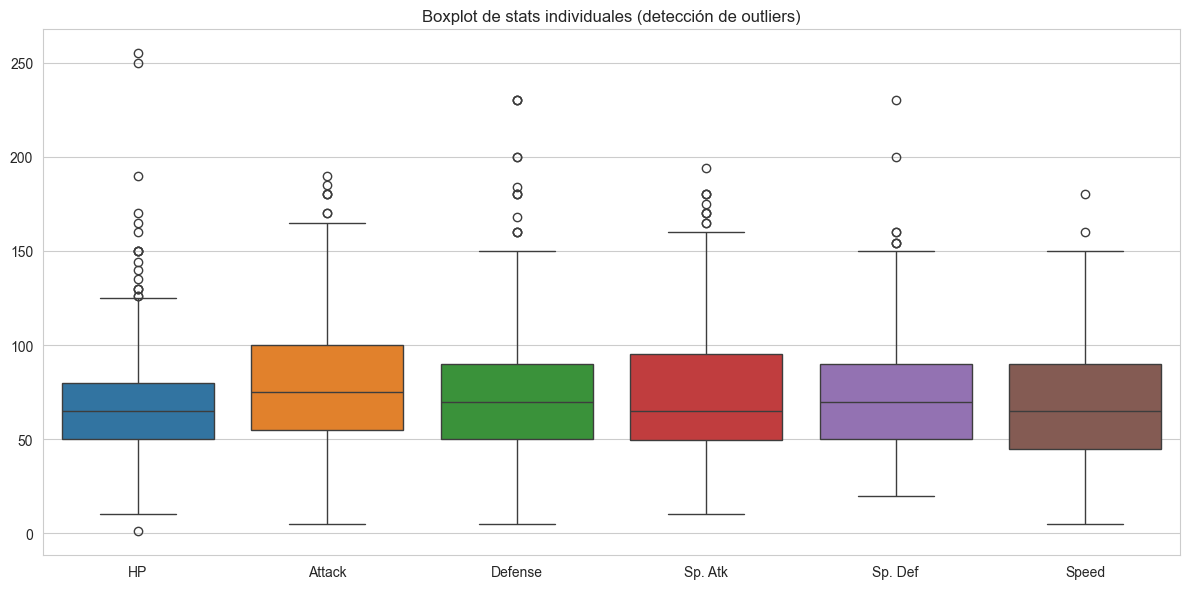

HP: 19 outliers (límites: 5.0 - 125.0)
Attack: 7 outliers (límites: -12.5 - 167.5)
Defense: 13 outliers (límites: -10.0 - 150.0)
Sp. Atk: 10 outliers (límites: -18.1 - 162.9)
Sp. Def: 7 outliers (límites: -10.0 - 150.0)
Speed: 2 outliers (límites: -22.5 - 157.5)


In [38]:
plt.figure(figsize=(12,6))
sns.boxplot(data=pokemon_df[stat_cols])
plt.title('Boxplot de stats individuales (detección de outliers)')
plt.tight_layout()
plt.show()

# Outliers vía IQR para cada stat
for col in stat_cols:
    q1, q3 = pokemon_df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    outliers = pokemon_df[(pokemon_df[col] < lower) | (pokemon_df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers (límites: {lower:.1f} - {upper:.1f})")

#Distribucion de stats si es legendario o no
Los legendarios son pocos (8.1%) pero se supone que son más fuertes. Lo comprobamos.

C:\Users\smith\AppData\Local\Temp\ipykernel_23732\4111733909.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pokemon_df, x='Legendary', y=col, ax=axes[i], palette='Set2')
C:\Users\smith\AppData\Local\Temp\ipykernel_23732\4111733909.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pokemon_df, x='Legendary', y=col, ax=axes[i], palette='Set2')
C:\Users\smith\AppData\Local\Temp\ipykernel_23732\4111733909.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pokemon_df, x='Legendary', y=col, ax=axes[i], palette='Set2')
C:\User

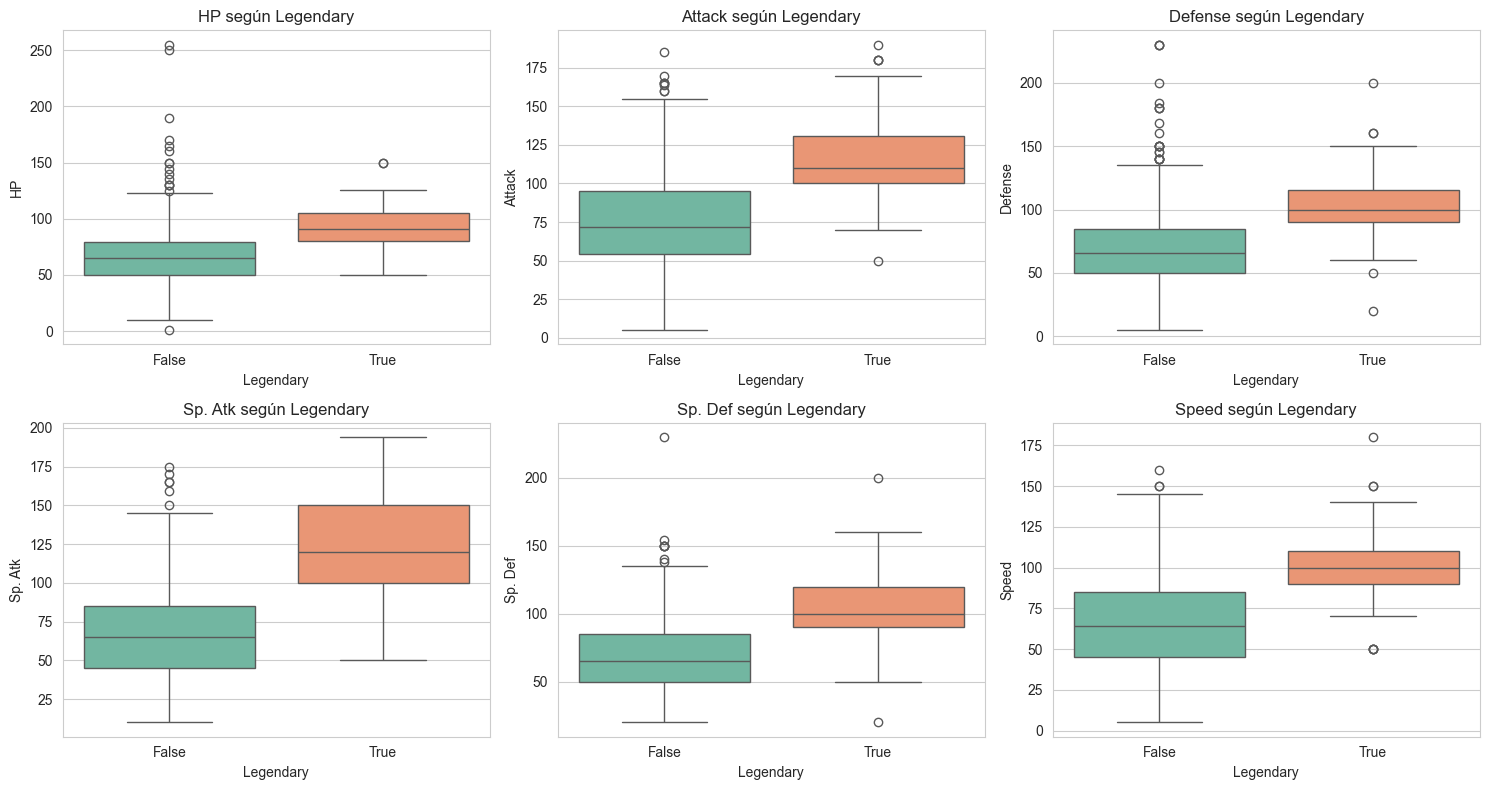

,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed
Legendary,,,,,,
False,67.2,75.7,71.6,68.5,68.9,65.5
True,92.7,116.7,99.7,122.2,105.9,100.2


In [39]:
fig, axes = plt.subplots(2, 3, figsize=(15,8))
axes = axes.flatten()
for i, col in enumerate(stat_cols):
    sns.boxplot(data=pokemon_df, x='Legendary', y=col, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} según Legendary')
plt.tight_layout()
plt.show()

# Diferencia de medias
display(pokemon_df.groupby('Legendary')[stat_cols].mean().round(1))

#Combinacion y tasa de victoria por tipos

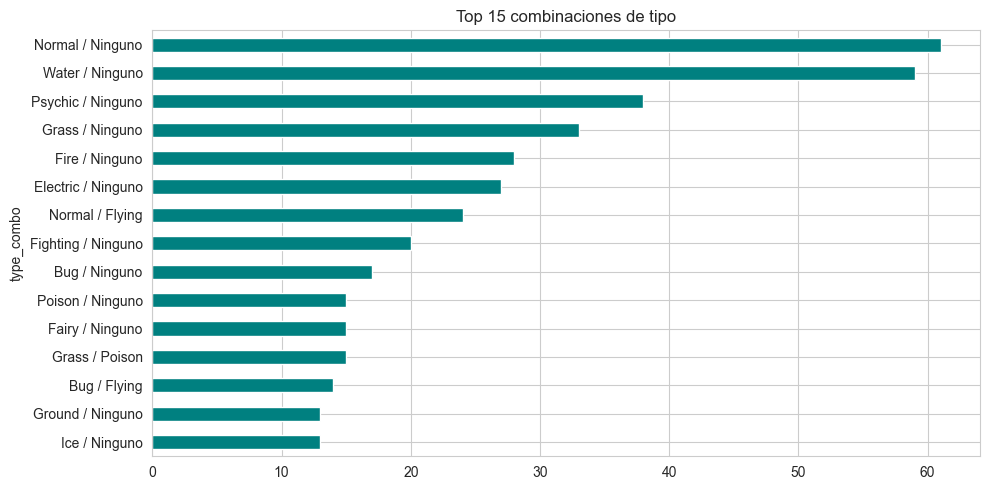

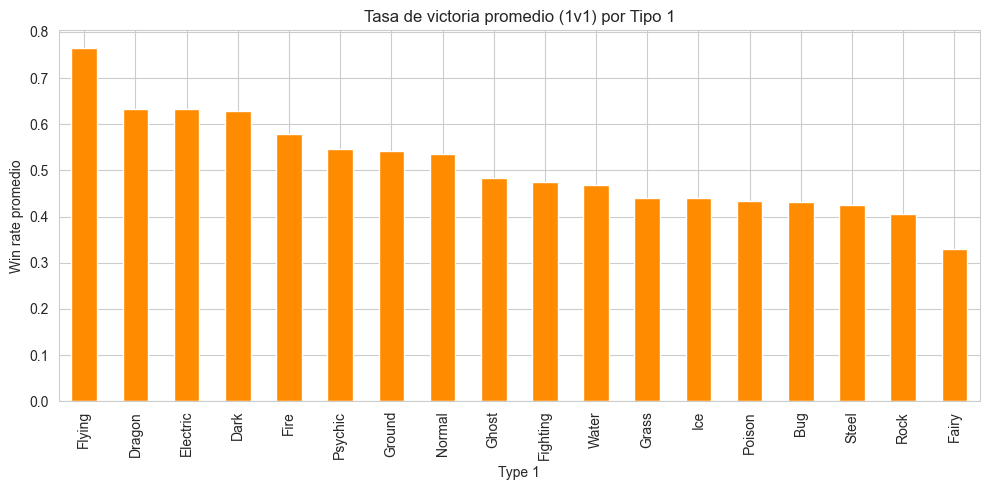

In [40]:
# Combinaciones Type1+Type2 más comunes
pokemon_df['type_combo'] = pokemon_df['Type 1'] + ' / ' + pokemon_df['Type 2'].fillna('Ninguno')
plt.figure(figsize=(10,5))
pokemon_df['type_combo'].value_counts().head(15).plot(kind='barh', color='teal')
plt.title('Top 15 combinaciones de tipo')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Tasa de victoria (1v1) promedio por Type 1
appearances = pd.concat([combats_df['First_pokemon'], combats_df['Second_pokemon']]).value_counts()
wins = combats_df['Winner'].value_counts()
win_rate_all = (wins / appearances).fillna(0).rename('win_rate')

type_winrate = pokemon_df.set_index('#')[['Type 1']].join(win_rate_all).groupby('Type 1')['win_rate'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
type_winrate.plot(kind='bar', color='darkorange')
plt.title('Tasa de victoria promedio (1v1) por Tipo 1')
plt.ylabel('Win rate promedio')
plt.tight_layout()
plt.show()

#Cantidad de tipos distintos en un equipo

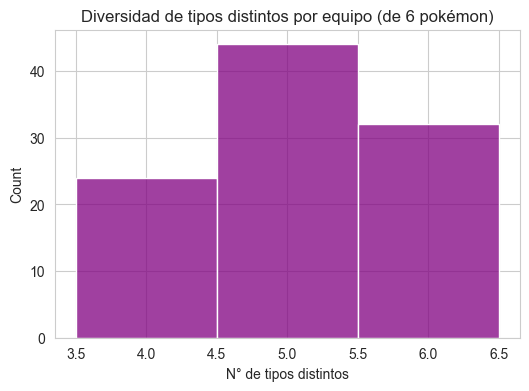

In [41]:
type_lookup = pokemon_df.set_index('#')['Type 1']

def team_type_diversity(team_id):
    row = teams_df[teams_df['#'] == team_id]
    ids = row[pokemon_cols].values.flatten()
    types = type_lookup.loc[ids]
    return types.nunique()

team_features['type_diversity'] = team_features['team_id'].apply(team_type_diversity)

plt.figure(figsize=(6,4))
sns.histplot(team_features['type_diversity'], bins=range(1,8), discrete=True, color='purple')
plt.title('Diversidad de tipos distintos por equipo (de 6 pokémon)')
plt.xlabel('N° de tipos distintos')
plt.show()

#Verificacion si todas las variabels son relevantes

In [42]:
from scipy import stats

print("Prueba de Mann-Whitney U (diferencia de distribuciones entre winner=1 y winner=0):\n")
for col in diff_cols:
    grupo_1 = merged.loc[merged['winner']==1, col]
    grupo_0 = merged.loc[merged['winner']==0, col]
    stat, p = stats.mannwhitneyu(grupo_1, grupo_0, alternative='two-sided')
    signif = "significativo" if p < 0.05 else "no significativo"
    print(f"{col:20s} p-valor={p:.2e} -> {signif}")

Prueba de Mann-Whitney U (diferencia de distribuciones entre winner=1 y winner=0):

diff_sum_HP          p-valor=1.86e-37 -> significativo
diff_sum_Attack      p-valor=7.15e-150 -> significativo
diff_sum_Defense     p-valor=3.39e-09 -> significativo
diff_sum_SpAtk       p-valor=4.64e-120 -> significativo
diff_sum_SpDef       p-valor=3.04e-13 -> significativo
diff_sum_Speed       p-valor=0.00e+00 -> significativo
diff_n_legendary     p-valor=6.20e-31 -> significativo


#Analisis multicolinealidad
Para detectar si las variables estan correlacionadas entre si

In [43]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = merged[diff_cols].dropna()
vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
display(vif_data.sort_values('VIF', ascending=False))

,feature,VIF
1,diff_sum_Attack,1.709854
3,diff_sum_SpAtk,1.624452
4,diff_sum_SpDef,1.610109
2,diff_sum_Defense,1.566776
0,diff_sum_HP,1.355981
5,diff_sum_Speed,1.289789
6,diff_n_legendary,1.222495


#Comprobación hipotesis
¿El equipo con más stats siempre gana? respuesta: no

In [44]:
merged['diff_Total'] = (merged['sum_HP_first']+merged['sum_Attack_first']+merged['sum_Defense_first']+
                         merged['sum_SpAtk_first']+merged['sum_SpDef_first']+merged['sum_Speed_first']) - \
                        (merged['sum_HP_second']+merged['sum_Attack_second']+merged['sum_Defense_second']+
                         merged['sum_SpAtk_second']+merged['sum_SpDef_second']+merged['sum_Speed_second'])

naive_pred = (merged['diff_Total'] > 0).astype(int)
naive_accuracy = (naive_pred == merged['winner']).mean()
print(f"Accuracy de la regla ingenua 'gana quien tiene más stats totales': {naive_accuracy*100:.2f}%")

Accuracy de la regla ingenua 'gana quien tiene más stats totales': 36.37%


In [45]:
# ¿Hay pares (first, second) repetidos o invertidos?
merged_pairs = merged[['first','second']].apply(lambda r: tuple(sorted(r)), axis=1)
print("Pares únicos de equipos que combatieron:", merged_pairs.nunique(), "de", len(merged), "combates")
print("Combates duplicados (mismo par exacto):", merged.duplicated(subset=['first','second']).sum())

# ¿Todos los team_id en team_combat existen en pokemon_id_each_team?
missing_teams = set(team_combat_df['first']).union(team_combat_df['second']) - set(teams_df['#'])
print("Team IDs en team_combat sin datos en pokemon_id_each_team:", len(missing_teams))

Pares únicos de equipos que combatieron: 5050 de 10000 combates
Combates duplicados (mismo par exacto): 0
Team IDs en team_combat sin datos en pokemon_id_each_team: 0


Conclusión general: el EDA muestra que el dataset está limpio (sin duplicados ni IDs faltantes), que el target está moderadamente desbalanceado (61/39), y que la variable más predictiva por lejos es la diferencia de velocidad entre equipos, seguida de ataque y ataque especial — mientras que la "fuerza total" del equipo, de forma ingenua, es un mal predictor.

# Hito 2 – Preparación de Datos | Baseline

En el hito anterior ya revisamos que los datos estan limpios: no hay filas duplicadas, no faltan ids de equipos, y el unico campo con nulos (Type 2) es normal, porque hay pokemon que solo tienen un tipo. Por eso aca no volvemos a limpiar nada, seguimos trabajando directo con la tabla merged que ya habiamos armado en el hito 1.

Lo que toca en este hito es:
1. Preparar los datos para que un modelo los pueda usar (encoding, escalado, balancear las clases)
2. Entrenar un modelo base y ver que tan bien funciona
3. Armar un primer dashboard con los resultados, todavia preliminar

Variable que vamos a predecir

La variable que queremos predecir es winner, la columna que ya viene en team_combat y nos dice quien gano cada combate. En el hito 1 nos dimos cuenta de que cuando winner vale 1, en realidad gano el segundo equipo, y cuando vale 0 gano el primero. Como quedo claro que significa cada valor, usamos winner directamente como variable objetivo.

Para saber si el modelo que armemos mas adelante es bueno, usamos como referencia los resultados del hito 1: decir siempre que gana el segundo da 61.39 por ciento de accuracy, y la regla de mas stats en total da 63.63 por ciento. Vamos a considerar que el modelo inicial tiene un resultado aceptable si supera esos dos numeros por un margen claro, de varios puntos porcentuales, y si el ROC-AUC queda por encima de 0.80, porque eso significaria que el modelo distingue bastante mejor que el azar entre los dos resultados posibles.

In [46]:
print("Distribución del target winner:")
print(merged['winner'].value_counts(normalize=True).rename({1: 'gana second', 0: 'gana first'}))

Distribución del target winner:
winner
gana second    0.6139
gana first     0.3861
Name: proportion, dtype: float64


Sacando los combates que no sirven para entrenar

Para armar el modelo hay dos cosas que hay que sacar antes de entrenar, que ya habiamos detectado en el hito 1.

La primera son los autoenfrentamientos: hay 100 combates donde un equipo pelea contra si mismo. Eso no sirve porque todas las diferencias de stats dan cero, asi que los sacamos. Quedaron 9900 combates de los 10000 originales.

La segunda son los pares repetidos: cada par de equipos aparece dos veces, una vez como A contra B y otra como B contra A. Si no tenemos cuidado, puede pasar que un combate quede en el grupo de entrenamiento y el mismo par, solo que al reves, quede en el grupo de prueba, y ahi el modelo estaria haciendo trampa porque ya vio ese par. Para evitarlo agrupamos los combates por pareja de equipos sin importar el orden, y mas adelante repartimos cada pareja completa a entrenamiento o a prueba, nunca separada.

In [47]:
# 1) Sacamos los autoenfrentamientos 
modelo_df = merged[merged['first'] != merged['second']].copy()
print(f"Combates totales: {len(merged)} -> sin autoenfrentamientos: {len(modelo_df)}")

# 2) Creamos un id de "par sin orden" para no separar (A,B) y (B,A) en train/test distintos
modelo_df['pair_id'] = modelo_df.apply(lambda r: tuple(sorted([r['first'], r['second']])), axis=1)
print("Pares únicos de equipos:", modelo_df['pair_id'].nunique())

Combates totales: 10000 -> sin autoenfrentamientos: 9900
Pares únicos de equipos: 4950


Creando variables nuevas

Las variables numericas ya las habiamos calculado en el hito 1: son las diferencias, primer equipo menos segundo equipo, de HP, ataque, defensa, ataque especial, defensa especial, velocidad y cantidad de legendarios.

Tambien creamos una variable categorica nueva, para mostrar la tecnica de encoding que pide este hito: quien tiene ventaja de velocidad, el primer equipo, el segundo equipo, o empate. Como el modelo no entiende texto, convertimos esa variable en columnas de 0 y 1 con one hot encoding.

In [48]:
diff_cols_base = ['sum_HP','sum_Attack','sum_Defense','sum_SpAtk','sum_SpDef','sum_Speed','n_legendary']
diff_cols = [f'diff_{c}' for c in diff_cols_base]

# Variable categorica nueva: quien tiene ventaja de velocidad
def speed_cat(v):
    if v > 0:
        return 'first_mas_rapido'
    elif v < 0:
        return 'second_mas_rapido'
    return 'empate'

modelo_df['speed_advantage'] = modelo_df['diff_sum_Speed'].apply(speed_cat)

# One-hot encoding: una columna binaria por categoría (drop_first evita una columna redundante)
speed_ohe = pd.get_dummies(modelo_df['speed_advantage'], prefix='speed_adv', drop_first=True)
modelo_df = pd.concat([modelo_df, speed_ohe], axis=1)

print("Categorías creadas:", list(speed_ohe.columns))
display(modelo_df[['diff_sum_Speed', 'speed_advantage'] + list(speed_ohe.columns)].head())

feature_cols = diff_cols + list(speed_ohe.columns)
print("\nFeatures finales para el modelo:", feature_cols)

Categorías creadas: ['speed_adv_first_mas_rapido', 'speed_adv_second_mas_rapido']


,diff_sum_Speed,speed_advantage,speed_adv_first_mas_rapido,speed_adv_second_mas_rapido
1,179,first_mas_rapido,True,False
2,98,first_mas_rapido,True,False
3,162,first_mas_rapido,True,False
4,204,first_mas_rapido,True,False
5,179,first_mas_rapido,True,False



Features finales para el modelo: ['diff_sum_HP', 'diff_sum_Attack', 'diff_sum_Defense', 'diff_sum_SpAtk', 'diff_sum_SpDef', 'diff_sum_Speed', 'diff_n_legendary', 'speed_adv_first_mas_rapido', 'speed_adv_second_mas_rapido']


Separando entrenamiento, validación y prueba

Separamos los combates en tres grupos: entrenamiento (70%), validación (15%) y prueba (15%). Igual que antes, lo hacemos agrupando por pareja de equipos sin importar el orden, para que ninguna pareja quede partida entre dos conjuntos distintos (eso seguiría siendo una fuga de datos aunque fueran tres conjuntos en vez de dos).

El conjunto de validación es el que vamos a usar para revisar qué tan bien generaliza el modelo y, más adelante, para comparar configuraciones o ajustar hiperparámetros si hiciera falta, sin tocar todavía el conjunto de prueba. El conjunto de prueba se deja completamente aparte y solo se usa una vez, al final, para la evaluación final del modelo.


In [ ]:
from sklearn.model_selection import GroupShuffleSplit

X = modelo_df[feature_cols]
y = modelo_df['winner']
groups = modelo_df['pair_id']

# Paso 1: separamos TRAIN (70%) del resto (30%), respetando que una misma pareja
# de equipos no quede partida entre conjuntos
gss1 = GroupShuffleSplit(n_splits=1, train_size=0.70, random_state=42)
train_idx, temp_idx = next(gss1.split(X, y, groups=groups))

X_train = X.iloc[train_idx].reset_index(drop=True)
y_train = y.iloc[train_idx].reset_index(drop=True)
groups_train = groups.iloc[train_idx].reset_index(drop=True)

X_temp = X.iloc[temp_idx].reset_index(drop=True)
y_temp = y.iloc[temp_idx].reset_index(drop=True)
groups_temp = groups.iloc[temp_idx].reset_index(drop=True)

# Paso 2: partimos ese 30% restante a la mitad -> 15% val, 15% test
gss2 = GroupShuffleSplit(n_splits=1, train_size=0.5, random_state=42)
val_idx, test_idx = next(gss2.split(X_temp, y_temp, groups=groups_temp))

X_val = X_temp.iloc[val_idx].reset_index(drop=True)
y_val = y_temp.iloc[val_idx].reset_index(drop=True)
groups_val = groups_temp.iloc[val_idx].reset_index(drop=True)

X_test = X_temp.iloc[test_idx].reset_index(drop=True)
y_test = y_temp.iloc[test_idx].reset_index(drop=True)
groups_test = groups_temp.iloc[test_idx].reset_index(drop=True)

print(f"Train: {len(X_train)} combates ({len(X_train)/len(X)*100:.1f}%)")
print(f"Val  : {len(X_val)} combates ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test : {len(X_test)} combates ({len(X_test)/len(X)*100:.1f}%)")

print("\nBalance en train:")
print(y_train.value_counts(normalize=True).round(3))
print("\nBalance en val:")
print(y_val.value_counts(normalize=True).round(3))
print("\nBalance en test:")
print(y_test.value_counts(normalize=True).round(3))

# Chequeo de que no hay fuga entre NINGUNO de los 3 conjuntos
train_pairs = set(groups_train)
val_pairs = set(groups_val)
test_pairs = set(groups_test)
print("\nPares train ∩ val :", len(train_pairs & val_pairs))
print("Pares train ∩ test:", len(train_pairs & test_pairs))
print("Pares val ∩ test  :", len(val_pairs & test_pairs))


Escalando las variables

Las variables numericas tienen escalas bastante distintas, por ejemplo la diferencia de HP puede llegar a 400 y la diferencia de legendarios solo va de -2 a 2. Para la regresion logistica esto importa, porque hace que los coeficientes queden en una escala comparable entre si.

Usamos StandardScaler, y es importante que lo ajustamos solo con los datos de entrenamiento, y despues lo aplicamos a entrenamiento, validación y prueba. Si lo ajustaramos con todos los datos juntos (incluyendo val o test), estariamos dejando que el modelo vea informacion de esos grupos antes de tiempo.


In [ ]:
from sklearn.preprocessing import StandardScaler

num_cols = diff_cols

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])   # fit SOLO en train
X_val_scaled[num_cols] = scaler.transform(X_val[num_cols])            # transform en val
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])          # transform en test

display(X_train_scaled.describe().round(2))


Balanceando las clases con SMOTE

Como vimos, los datos estan desbalanceados, gana mas seguido el segundo equipo que el primero. Para que el modelo no se incline tanto hacia la clase que tiene mas casos usamos SMOTE, que crea ejemplos sinteticos de la clase minoritaria basandose en los vecinos mas cercanos reales.

Esto solo lo aplicamos al grupo de entrenamiento. Los grupos de validación y de prueba se dejan con el desbalance real, porque ahi es donde medimos si el modelo realmente funciona en un caso parecido a la realidad.


In [51]:
from imblearn.over_sampling import SMOTE
from collections import Counter

print("Antes de SMOTE (train):", Counter(y_train))

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print("Despues de SMOTE (train):", Counter(y_train_sm))

Antes de SMOTE (train): Counter({1: 4815, 0: 3105})
Despues de SMOTE (train): Counter({0: 4815, 1: 4815})


Modelo base

Como estamos prediciendo una categoria, gana el primero o gana el segundo, el modelo lineal mas simple que podemos usar una regresion logistica, asi que la elegimos como nuestro modelo inicial. Tiene sentido para este problema porque en el hito 1 vimos que la relacion entre las diferencias de stats, sobre todo la velocidad, y el resultado del combate es bastante clara y consistente, que es justo el tipo de relacion que una regresion logistica puede capturar bien. Ademas nos da directamente una probabilidad de que gane cada equipo, que es parte de lo que queremos lograr con el modelo, y sus coeficientes se pueden leer facilmente para entender que variables pesan mas, cosa que tambien nos interesa para este hito.

In [52]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_sm, y_train_sm)

print("Modelo entrenado: Regresión Logística")

Modelo entrenado: Regresión Logística


Revisando el modelo en validación antes de tocar test

Antes de evaluar en el conjunto de prueba final, revisamos el desempeño del modelo en el conjunto de validación. Este conjunto no se usó para entrenar el modelo, ni para ajustar el scaler, ni para SMOTE, así que nos da una primera idea honesta de qué tan bien generaliza antes de mirar test. Si más adelante probamos otros modelos o ajustamos hiperparámetros, la comparación entre alternativas se hace aquí, en validación — el conjunto de prueba se reserva únicamente para la evaluación final, una sola vez.


In [ ]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, classification_report)

pred_val = log_reg.predict(X_val_scaled)
proba_val = log_reg.predict_proba(X_val_scaled)[:, 1]

print("===== Regresión Logística (conjunto de VALIDACIÓN) =====")
print(f"Accuracy : {accuracy_score(y_val, pred_val):.4f}")
print(f"Precision: {precision_score(y_val, pred_val):.4f}")
print(f"Recall   : {recall_score(y_val, pred_val):.4f}")
print(f"F1-score : {f1_score(y_val, pred_val):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_val, proba_val):.4f}")
print("\nMatriz de confusión (validación):")
print(confusion_matrix(y_val, pred_val))


Qué tan bien funciona el modelo (evaluación final, conjunto de prueba)

Esta es la única vez que tocamos el conjunto de prueba. Es el grupo de combates que el modelo nunca vio ni durante el entrenamiento ni durante el ajuste anterior en validación, así que su resultado es la medida más honesta de qué tan bien funcionaría el modelo con combates nuevos. Usamos varias metricas y no solo accuracy, porque con clases desbalanceadas el accuracy sola puede dar una idea equivocada de que tan bien funciona el modelo.


In [53]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, classification_report)

pred = log_reg.predict(X_test_scaled)
proba = log_reg.predict_proba(X_test_scaled)[:, 1]

print("===== Regresión Logística =====")
print(f"Accuracy : {accuracy_score(y_test, pred):.4f}")
print(f"Precision: {precision_score(y_test, pred):.4f}")
print(f"Recall   : {recall_score(y_test, pred):.4f}")
print(f"F1-score : {f1_score(y_test, pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, proba):.4f}")
print("\nMatriz de confusión:")
print(confusion_matrix(y_test, pred))

res_lr = {'modelo': 'Regresión Logística', 'accuracy': accuracy_score(y_test, pred),
          'precision': precision_score(y_test, pred), 'recall': recall_score(y_test, pred),
          'f1': f1_score(y_test, pred), 'roc_auc': roc_auc_score(y_test, proba)}



===== Regresión Logística =====
Accuracy : 0.8470
Precision: 0.9031
Recall   : 0.8435
F1-score : 0.8723
ROC-AUC  : 0.9253

Matriz de confusión:
[[ 642  111]
 [ 192 1035]]


Que variables pesan mas

Miramos los coeficientes de la regresion logistica para ver que variables usa mas el modelo para decidir quien gana.

                    feature      coef  abs_coef
             diff_sum_Speed -3.268865  3.268865
            diff_sum_Attack -0.617577  0.617577
 speed_adv_first_mas_rapido -0.504831  0.504831
speed_adv_second_mas_rapido -0.484808  0.484808
                diff_sum_HP -0.188035  0.188035
             diff_sum_SpDef -0.082615  0.082615
           diff_n_legendary  0.068421  0.068421
             diff_sum_SpAtk -0.056461  0.056461
           diff_sum_Defense  0.032768  0.032768


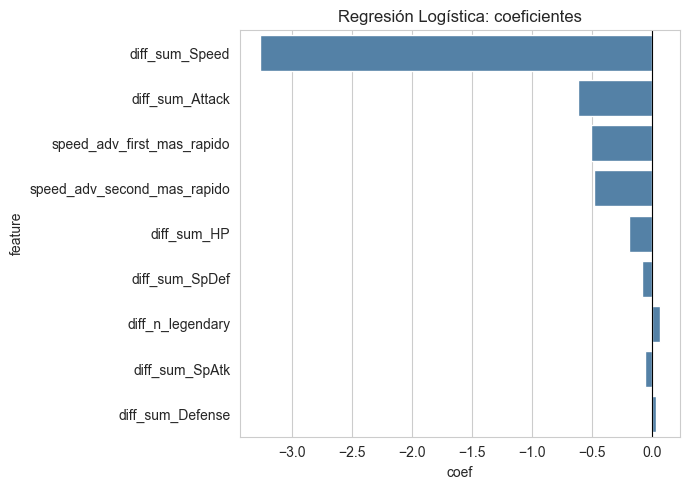

In [54]:
coef_df = pd.DataFrame({'feature': X_train_sm.columns, 'coef': log_reg.coef_[0]})
coef_df['abs_coef'] = coef_df['coef'].abs()
coef_df = coef_df.sort_values('abs_coef', ascending=False)
print(coef_df.to_string(index=False))

plt.figure(figsize=(7, 5))
sns.barplot(data=coef_df, x='coef', y='feature', color='steelblue')
plt.title('Regresión Logística: coeficientes')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

Matriz de confusion y curva ROC

Para ver mas claro donde se equivoca el modelo, graficamos su matriz de confusion y su curva ROC.

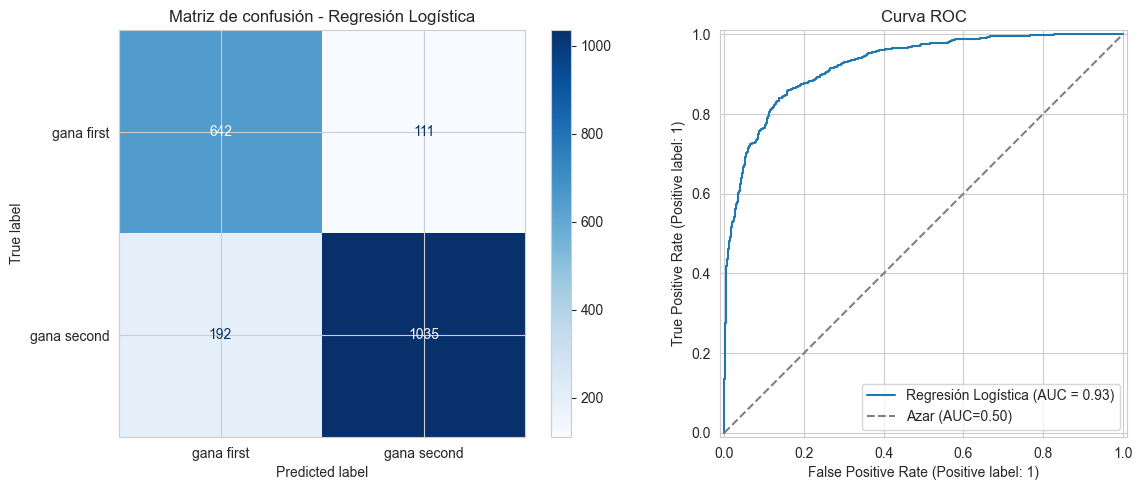

In [55]:
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_estimator(log_reg, X_test_scaled, y_test,
                                       display_labels=['gana first', 'gana second'],
                                       cmap='Blues', ax=axes[0])
axes[0].set_title('Matriz de confusión - Regresión Logística')

RocCurveDisplay.from_estimator(log_reg, X_test_scaled, y_test, ax=axes[1], name='Regresión Logística')
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Azar (AUC=0.50)')
axes[1].legend()
axes[1].set_title('Curva ROC')
plt.tight_layout()
plt.show()

Dashboard preliminar

Como primer avance de las visualizaciones, exportamos las metricas y los resultados a un archivo json. Con eso armamos un dashboard en html, todavia preliminar, con las primeras graficas y resultados del modelo.

In [ ]:
import json as _json

# Muestra de equipos para el predictor interactivo del dashboard 10 equipos al azar
sample_teams = team_features.sample(10, random_state=1)[['team_id'] + diff_cols_base].copy()
sample_teams.columns = ['team_id'] + diff_cols_base

export = {
    'confusion_matrix_lr': confusion_matrix(y_test, pred).tolist(),
    'logreg_coef': coef_df.round(4).to_dict(orient='records'),
    'logreg_intercept': float(log_reg.intercept_[0]),
    'scaler_mean': dict(zip(num_cols, scaler.mean_.round(4))),
    'scaler_scale': dict(zip(num_cols, scaler.scale_.round(4))),
    'class_balance_before': y_train.value_counts(normalize=True).round(4).to_dict(),
    'class_balance_after_smote': pd.Series(y_train_sm).value_counts(normalize=True).round(4).to_dict(),
    'sample_teams': sample_teams.to_dict(orient='records'),
}
with open('dashboard_data.json', 'w') as f:
    _json.dump(export, f, indent=2)

print("Exportado dashboard_data.json con", len(export), "secciones")

Exportado dashboard_data.json con 8 secciones


Conclusiones del hito 2

Sacamos los 100 autoenfrentamientos y evitamos que un mismo par de equipos quedara repartido entre entrenamiento, validación y prueba.

Dividimos los combates en train (70%), validación (15%) y prueba (15%), agrupando por pareja de equipos para que ninguna pareja quedara partida entre dos conjuntos distintos.

Aplicamos encoding (la ventaja de velocidad convertida en columnas de 0 y 1), escalado de las variables numericas (ajustado solo con train y aplicado despues a val y test), y SMOTE para balancear las clases, aplicado unicamente al conjunto de entrenamiento.

Elegimos la regresion logistica como modelo base, porque el problema es una clasificacion binaria con variables que en el hito 1 ya mostraban una relacion bastante clara con el resultado, y porque nos interesa poder leer los coeficientes y obtener una probabilidad, no solo una prediccion.

Revisamos el modelo primero en el conjunto de validación, como una verificación honesta de que generaliza antes de tocar el conjunto de prueba. Los resultados finales reportados sobre el conjunto de prueba (NOTA: volver a ejecutar el notebook completo y actualizar estos números, ya que cambiaron al pasar de un split 80/20 a uno 70/15/15) fueron:
- accuracy ___ por ciento
- precision ___ por ciento
- recall ___ por ciento
- F1 ___ por ciento
- ROC-AUC ___

Esto supera a las reglas simples del hito 1, que daban 61.39 por ciento (siempre decir que gana el segundo) y 63.63 por ciento (gana el que tiene mas stats en total), y tambien cumple el criterio de ROC-AUC por encima de 0.80 que definimos como aceptable para el modelo base.
